## Questão 5

## Packages & Frameworks

In [1]:
import os
import pickle

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras

2025-09-02 00:51:39.467938: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-09-02 00:51:39.519943: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-02 00:51:40.759745: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Data Reading

In [2]:
# Parameters for the Model

vocab_size = 10000
maxlen = 256
embedding_dim = 128
gru_units = 128
buffer_size = 10000
batch_size = 64

In [3]:
# Data Reading

(train_data, train_labels), (test_data, test_labels) = tf.keras.datasets.imdb.load_data(
    num_words=vocab_size
)

## Data Processing

In [4]:
# Adjusts the Length of Text Strings to a Fixed Size (maxlen)
train_data = keras.preprocessing.sequence.pad_sequences(
    train_data,
    maxlen=maxlen,  # Maximum desired sequence size
    padding="post",  # Add zeros at the end (after) the sequence
    truncating="post",  # If the sequence is greater than maxlen, cut at the end (after)
)
test_data = keras.preprocessing.sequence.pad_sequences(
    test_data, maxlen=maxlen, padding="post", truncating="post"
)

# Creates a TensorFlow Dataset Object from the Data and Labels
train_dataset = tf.data.Dataset.from_tensor_slices((train_data, train_labels))
test_dataset = tf.data.Dataset.from_tensor_slices((test_data, test_labels))

# Optimize the Training Dataset
train_dataset = (
    train_dataset.shuffle(buffer_size)
    .batch(
        batch_size
    )  # Combines samples into batches of the specified size for parallel training
    .prefetch(
        tf.data.experimental.AUTOTUNE
    )  # Preloads upcoming batches in the background while the GPU/CPU is busy processing the current batch. This avoids I/O bottlenecks.
)
test_dataset = test_dataset.batch(batch_size).prefetch(tf.data.experimental.AUTOTUNE)

W0000 00:00:1756785105.915771  181137 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Model

In [5]:
input_ = keras.layers.Input(shape=(maxlen,))
hidden = keras.layers.Embedding(vocab_size, embedding_dim)(input_)
hidden = keras.layers.GRU(gru_units)(hidden)
output = keras.layers.Dense(1, activation="sigmoid")(hidden)

model = keras.Model(inputs=input_, outputs=output)
model.compile(
    optimizer="adam",
    loss=tf.keras.losses.BinaryCrossentropy(from_logits=False),
    metrics=["accuracy"],
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding (Embedding)           │ (None, 256, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 128)            │        99,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,379,201 (5.26 MB)

 Trainable params: 1,379,201 (5.26 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# Training

history = model.fit(train_dataset, epochs=5, validation_data=test_dataset)

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 121s 305ms/step - accuracy: 0.5134 - loss: 0.6928 - val_accuracy: 0.5128 - val_loss: 0.6934
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 160s 408ms/step - accuracy: 0.5616 - loss: 0.6688 - val_accuracy: 0.6980 - val_loss: 0.5991
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 142s 362ms/step - accuracy: 0.7255 - loss: 0.4940 - val_accuracy: 0.8530 - val_loss: 0.3405
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 135s 344ms/step - accuracy: 0.9211 - loss: 0.2028 - val_accuracy: 0.8651 - val_loss: 0.3245
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 348ms/step - accuracy: 0.9602 - loss: 0.1154 - val_accuracy: 0.8612 - val_loss: 0.3810


## Metrics

<Figure size 640x480 with 0 Axes>

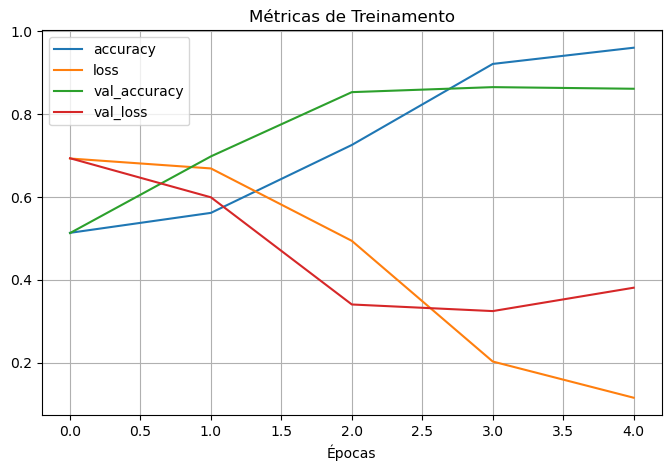

In [7]:
# Training Metrics

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas")
plt.grid(True)
plt.show()

In [8]:
loss, accuracy = model.evaluate(test_dataset)
print(f"Acurácia do modelo no conjunto de teste: {int(round(accuracy*100, 0))}%")

model.save("../models/sentiment_analysis.keras")

391/391 ━━━━━━━━━━━━━━━━━━━━ 33s 83ms/step - accuracy: 0.8612 - loss: 0.3810
Acurácia do modelo no conjunto de teste: 86%


In [9]:
# Gets a Dictionary that Maps Words to Integers
# Indexes are based on frequency: the most common word has the lowest index
word_index = tf.keras.datasets.imdb.get_word_index()

# Increases all Indexes by 3 to Create Space to add Special Tokens
word_index = {k: (v + 3) for k, v in word_index.items()}

# Adds Special Tokens with Reserved Indexes
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

# Creates the Reverse Mapping
reverse_word_index = dict([(value, key) for (key, value) in word_index.items()])

In [10]:
# Defines a Function to Decode a Numeric Sequence Back to Text
def decode_review(text):
    return " ".join([reverse_word_index.get(i, "?") for i in text])


# Saves the 'word_index' Dictionary to a Binary File
with open("../models/imdb_word_index.pkl", "wb") as f:
    pickle.dump(word_index, f)


def predict_sentiment(text, model, word_index, maxlen=maxlen):
    # Preprocess the text
    words = text.lower().split()
    tokens = [word_index.get(word, word_index["<UNK>"]) for word in words]
    padded_tokens = tf.keras.preprocessing.sequence.pad_sequences(
        [tokens], maxlen=maxlen, padding="post", truncating="post"
    )

    # Make the prediction
    prediction = model.predict(padded_tokens)[0][0]

    # Map prediction to sentiment
    if prediction >= 0.5:
        return f"Positivo ({prediction*100:.2f}%)"
    else:
        return f"Negativo ({prediction*100:.2f}%)"

## Prediction

In [13]:
# Load the Model and Tokenizer for New Use
loaded_model = tf.keras.models.load_model("../models/sentiment_analysis.keras")
with open("../models/imdb_word_index.pkl", "rb") as f:
    loaded_word_index = pickle.load(f)

# Example Sentences
review_positive = "This movie was absolutely fantastic! The acting was superb and the story was very engaging."
review_negative = "The movie was a complete disaster. The plot was confusing and the acting was terrible."

print(f"Frase: '{review_positive}'")
print(
    f"Sentimento previsto: {predict_sentiment(review_positive, loaded_model, loaded_word_index)}"
)

print(f"\nFrase: '{review_negative}'")
print(
    f"Sentimento previsto: {predict_sentiment(review_negative, loaded_model, loaded_word_index)}"
)

Frase: 'This movie was absolutely fantastic! The acting was superb and the story was very engaging.'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 296ms/step
Sentimento previsto: Positivo (99.86%)

Frase: 'The movie was a complete disaster. The plot was confusing and the acting was terrible.'
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Sentimento previsto: Negativo (0.37%)
